In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
from mad.utils.ballistic_tables import load_ballistic_csv

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
table_name = "V1"
df = load_ballistic_csv(table_name)

df

,altitude_m,velocity_m_s,gamma_rad,range_rad,range_km,altitude_km,gamma_deg
0,100.0,100.0,-0.349066,0.000044,0.280190,0.10,-20.0
1,100.0,100.0,-0.314159,0.000045,0.283581,0.10,-18.0
2,100.0,100.0,-0.279253,0.000045,0.286627,0.10,-16.0
3,100.0,100.0,-0.244346,0.000045,0.289324,0.10,-14.0
4,100.0,100.0,-0.209440,0.000046,0.291669,0.10,-12.0
...,...,...,...,...,...,...,...
3595,950.0,190.0,0.174533,0.000498,3.170358,0.95,10.0
3596,950.0,190.0,0.209440,0.000520,3.314789,0.95,12.0
3597,950.0,190.0,0.244346,0.000542,3.452195,0.95,14.0
3598,950.0,190.0,0.279253,0.000562,3.582095,0.95,16.0


In [44]:
df["altitude_m"].unique()

array([100., 150., 200., 250., 300., 350., 400., 450., 500., 550., 600.,
       650., 700., 750., 800., 850., 900., 950.])

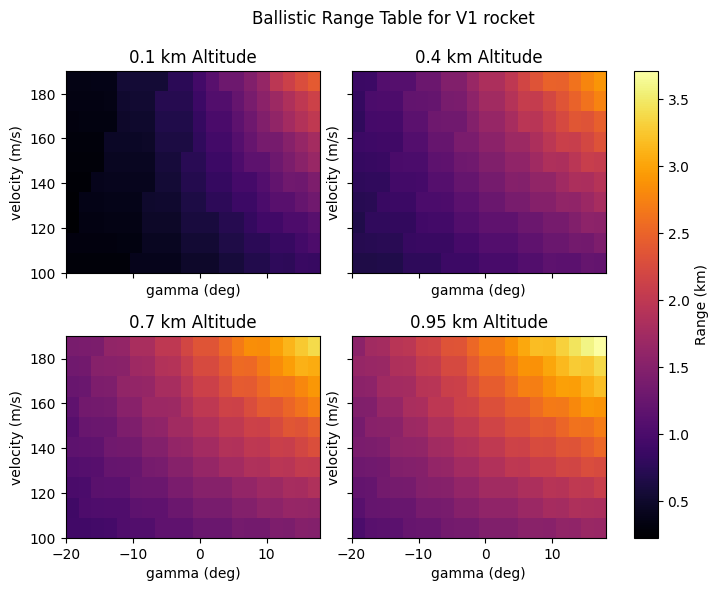

In [49]:
def plot_ballistic_range_table(df, selected_altitudes_km, table_name):
    fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(8, 6), sharex=True, sharey=True)
    ax = ax.ravel()

    # Compute global vmin/vmax across all selected altitudes for a shared colorscale
    dfs = [df[df["altitude_km"] == alt].pivot(index="velocity_m_s", columns="gamma_deg", values="range_km")
        for alt in selected_altitudes_km]
    vmin = min(d.values.min() for d in dfs if not d.empty)
    vmax = max(d.values.max() for d in dfs if not d.empty)

    imgs = []
    for i, (selected_altitude, df2) in enumerate(zip(selected_altitudes_km, dfs)):
        if df2.empty:
            continue
        img = ax[i].imshow(
            df2.values,
            extent=(df2.columns.min(), df2.columns.max(), df2.index.min(), df2.index.max()),
            aspect="auto",
            origin="lower",
            vmin=vmin,
            vmax=vmax,
            cmap="inferno",
        )
        imgs.append(img)
        ax[i].set_xlabel("gamma (deg)")
        ax[i].set_ylabel("velocity (m/s)")
        ax[i].set_title(f"{selected_altitude} km Altitude")

    fig.suptitle(f"Ballistic Range Table for {table_name}")
    fig.tight_layout(pad=1.2)
    cbar = fig.colorbar(imgs[0], ax=ax, fraction=0.2, pad=0.04, label="Range (km)")


selected_altitudes_km = [0.1, 0.4, 0.7, 0.95]  # km
plot_ballistic_range_table(df, selected_altitudes_km, "V1 rocket")

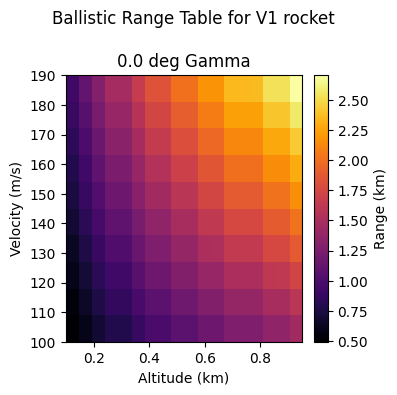

In [51]:
selected_gamma = 0.0 # deg

def plot_ballistic_range_table_gamma(df, selected_gamma, table_name, ax=None):
    output_fig = False
    if ax is None:
        fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(4, 4))
        output_fig = True

    # Compute global vmin/vmax across all selected altitudes for a shared colorscale
    dfs = df[df["gamma_deg"] == selected_gamma].pivot(index="velocity_m_s", columns="altitude_km", values="range_km")
    vmin = dfs.values.min()
    vmax = dfs.values.max()

    img = ax.imshow(
        dfs.values,
        extent=(dfs.columns.min(), dfs.columns.max(), dfs.index.min(), dfs.index.max()),
        aspect="auto",
        origin="lower",
            vmin=vmin,
            vmax=vmax,
            cmap="inferno",
        )

    ax.set_xlabel("Altitude (km)")
    ax.set_ylabel("Velocity (m/s)")
    ax.set_title(f"{selected_gamma} deg Gamma")

    if output_fig:
        fig.suptitle(f"Ballistic Range Table for {table_name}")
        fig.tight_layout(pad=1.2)
        cbar = fig.colorbar(img, ax=ax, fraction=0.2, pad=0.04, label="Range (km)")

plot_ballistic_range_table_gamma(df, 0.0, "V1 rocket")